In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 36.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.

Note that authentication is required to access data through the package, please follow the instructions [here](https://malariagen.github.io/vector-data/vobs/vobs-data-access.html).

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [ ]:
#import os
#os.environ["MGEN_SHOW_PROGRESS"] = "0"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1/
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : South Carolina, United States (Google Cloud us-east1)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
trra_haps = ag3.haplotypes(region="3L:36938555 - 36949962",
                           sample_sets="3.0")

In [ ]:
tpp_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(trra_haps["variant_position"].values))
pos.shape

(3882,)

## Extract the haplotype itself

In [8]:
gt = trra_haps["call_genotype"].values

In [ ]:
gt.shape

(653, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [9]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [10]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(653, 5568)

In [ ]:
haps

<HaplotypeArray shape=(3882, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
pos

0,1,2,3,4,...,648,649,650,651,652
np.int32(7163636),np.int32(7163641),np.int32(7163644),np.int32(7163645),np.int32(7163647),...,np.int32(7165291),np.int32(7165292),np.int32(7165300),np.int32(7165301),np.int32(7165309)


## Define the Transcript and the Cohort to work with

In [57]:
transcript = "AGAP012053-RC"

In [12]:
cohorts = "admin1_year"

## Call the SNPs in that transcript

In [58]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/149 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/54 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/34224 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                       True   
                           C          NaN                       True   
                           T          NaN                       True   
       36938556 T          A          NaN                       True   
                           C          NaN                       True   
...                                                              ...   
       36949961 G          C          NaN                       True   
                           T          NaN                       True   
       36949962 T          A          NaN                       True   
                           C          NaN                       True   
                           G          NaN                       True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3L     36938555 G          A          NaN                  True       True   
                           C          NaN                  True       True   
                           T          NaN                  True       True   
       36938556 T          A          NaN                  True       True   
                           C          NaN                  True       True   
...                                                         ...        ...   
       36949961 G          C          NaN                  True       True   
                           T          NaN                  True       True   
       36949962 T          A          NaN                  True       True   
                           C          NaN                  True       True   
                           G          NaN                  True       True   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3L     36938555 G          A          NaN                         0.0   
                           C          NaN                         0.0   
                           T          NaN                         0.0   
       36938556 T          A          NaN                         0.0   
                           C          NaN                         0.0   
...                                                               ...   
       36949961 G          C          NaN                         0.0   
                           T          NaN                         0.0   
       36949962 T          A          NaN                         0.0   
                           C          NaN                         0.0   
                           G          NaN                         0.0   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                   0.041667   
                           C          NaN                   0.000000   
                           T          NaN                   0.041667   
       36938556 T          A          NaN                   0.000000   
                           C          NaN                   0.000000   
...                                                              ...   
       36949961 G          C          NaN                   0.000000   
                           T          NaN                   0.000000   
       36949962 T          A          NaN                   0.000000   
                           C          NaN                   0.000000   
                           G          NaN                   0.000000   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
3L     36938555 G          A          NaN                        0

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [59]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3L     36939080 C          T          G558S                     True   
       36940669 G          A          T545I                     True   
       36940743 T          G          E520D                    False   
       36940760 T          C          S515G                    False   
       36940892 T          A          K497N                    False   
...                                                              ...   
       36949458 G          T          P7Q                       True   
       36949461 T          A          K6I                       True   
       36949467 G          A          A4V                       True   
       36949473 A          G          L2S                      False   
       36949475 C          T          M1I                      False   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3L     36939080 C          T          G558S                True       True   
       36940669 G          A          T545I                True       True   
       36940743 T          G          E520D                True      False   
       36940760 T          C          S515G                True      False   
       36940892 T          A          K497N                True      False   
...                                                         ...        ...   
       36949458 G          T          P7Q                  True       True   
       36949461 T          A          K6I                  True       True   
       36949467 G          A          A4V                  True       True   
       36949473 A          G          L2S                  True      False   
       36949475 C          T          M1I                  True      False   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3L     36939080 C          T          G558S                  0.000000   
       36940669 G          A          T545I                  0.000000   
       36940743 T          G          E520D                  0.117284   
       36940760 T          C          S515G                  0.117284   
       36940892 T          A          K497N                  0.000000   
...                                                               ...   
       36949458 G          T          P7Q                    0.000000   
       36949461 T          A          K6I                    0.000000   
       36949467 G          A          A4V                    0.055556   
       36949473 A          G          L2S                    0.000000   
       36949475 C          T          M1I                    0.000000   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
3L     36939080 C          T          G558S                 0.038462   
       36940669 G          A          T545I                 0.000000   
       36940743 T          G          E520D                 0.769231   
       36940760 T          C          S515G                 0.769231   
       36940892 T          A          K497N                 0.000000   
...                                                              ...   
       36949458 G          T          P7Q                   0.000000   
       36949461 T          A          K6I                   0.000000   
       36949467 G          A          A4V                   0.000000   
       36949473 A          G          L2S                   0.000000   
       36949475 C          T          M1I                   0.000000   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
3L     36939080 C          T          G558S                 0.0060

## Extract the indexes

In [60]:
trrc_index = missense_variants[[]]
trrc_index


Empty DataFrame
Columns: []
Index: [(3L, 36939080, C, T, G558S), (3L, 36940669, G, A, T545I), (3L, 36940743, T, G, E520D), (3L, 36940760, T, C, S515G), (3L, 36940892, T, A, K497N), (3L, 36940899, A, T, F495Y), (3L, 36940903, T, G, T494P), (3L, 36940909, A, G, Y492H), (3L, 36940962, G, A, A474V), (3L, 36940967, G, C, D472E), (3L, 36940969, C, T, D472N), (3L, 36940994, C, G, M463I), (3L, 36941087, C, A, Q432H), (3L, 36941110, G, T, L425M), (3L, 36941113, T, C, I424V), (3L, 36941126, C, A, E419D), (3L, 36941129, C, G, K418N), (3L, 36941134, C, T, D417N), (3L, 36941136, T, G, E416A), (3L, 36941139, C, T, R415Q), (3L, 36941142, T, G, D414A), (3L, 36941149, A, T, C412S), (3L, 36941219, A, C, D388E), (3L, 36941230, C, T, A385T), (3L, 36941236, C, T, E383K), (3L, 36941238, G, T, A382E), (3L, 36941239, C, G, A382P), (3L, 36941296, A, C, Y363D), (3L, 36941319, C, T, G355D), (3L, 36941350, C, A, A345S), (3L, 36941406, C, T, R326H), (3L, 36941431, C, T, G318S), (3L, 36941490, G, A, A298V), (3L, 36941490, G, C, A298G), (3L, 36941544, G, C, A280G), (3L, 36941544, G, T, A280D), (3L, 36941550, C, G, S278T), (3L, 36941614, G, T, L257M), (3L, 36941932, G, C, P151A), (3L, 36941971, G, T, L138I), (3L, 36942056, G, C, A133G), (3L, 36942066, A, T, S130T), (3L, 36942129, C, T, D109N), (3L, 36942144, G, T, R104S), (3L, 36942146, G, A, A103V), (3L, 36942153, A, C, F101V), (3L, 36942161, C, A, S98I), (3L, 36942167, G, C, T96S), (3L, 36942177, C, T, D93N), (3L, 36942182, G, T, T91K), (3L, 36942221, A, G, L78S), (3L, 36942234, C, G, E74Q), (3L, 36942318, G, A, R46C), (3L, 36942320, A, C, M45R), (3L, 36949443, C, T, C12Y), (3L, 36949444, A, G, C12R), (3L, 36949453, G, A, P9S), (3L, 36949455, C, T, G8E), (3L, 36949456, C, T, G8R), (3L, 36949458, G, T, P7Q), (3L, 36949461, T, A, K6I), (3L, 36949467, G, A, A4V), (3L, 36949473, A, G, L2S), (3L, 36949475, C, T, M1I)]

[64 rows x 0 columns]

## Conver the object to a dataframe

In [61]:
trrc_df = pd.DataFrame(list(trrc_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
trrc_df

,contig,position,ref_allele,alt_allele,aa_change
0,3L,36939080,C,T,G558S
1,3L,36940669,G,A,T545I
2,3L,36940743,T,G,E520D
3,3L,36940760,T,C,S515G
4,3L,36940892,T,A,K497N
...,...,...,...,...,...
59,3L,36949458,G,T,P7Q
60,3L,36949461,T,A,K6I
61,3L,36949467,G,A,A4V
62,3L,36949473,A,G,L2S


## Sort the positions of the selected variants

In [62]:
pos_selected = allel.SortedIndex(sorted(trrc_df['position']))

In [41]:
pos_selected

0,1,2,3,4,...,49,50,51,52,53
np.int64(36939080),np.int64(36940669),np.int64(36940743),np.int64(36940760),np.int64(36940892),...,np.int64(36942182),np.int64(36942221),np.int64(36942234),np.int64(36942318),np.int64(36942320)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [63]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, ..., False, False, False])

## Use said file to select the haplotypes corresponding to the selected positions

In [64]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(24, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 1 1 ... 0 1 1 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [44]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [65]:
values_to_remove = get_missing_values(pos_selected, pos)

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [66]:
trrc_df2 = trrc_df[~trrc_df["position"].isin(values_to_remove)]
trrc_df2.shape

(24, 5)

## this creates a dataframe to show which mutations were not present and were subsequently removed

In [67]:
trrc_mut = trrc_df[trrc_df["position"].isin(values_to_remove)]
trrc_mut.shape

(40, 5)

In [68]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5567,1
1,4094,1474
2,5567,1
3,5567,1
4,4998,570
5,5567,1
6,5564,4
7,5540,28
8,5511,57
9,5566,2


## Define the function to compute the Lenwontin D'

In [69]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [70]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [71]:
trrc_df2["label"] = (
    trrc_df2["position"].astype(str)
    + ": "
    + trrc_df2["ref_allele"].astype(str)
    + ">"
    + trrc_df2["alt_allele"].astype(str)
    + " "
    + trrc_df2["aa_change"]
)
trrc_df2

/tmp/ipython-input-197433779.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
1,3L,36940669,G,A,T545I,36940669: G>A T545I
5,3L,36940899,A,T,F495Y,36940899: A>T F495Y
6,3L,36940903,T,G,T494P,36940903: T>G T494P
7,3L,36940909,A,G,Y492H,36940909: A>G Y492H
14,3L,36941113,T,C,I424V,36941113: T>C I424V
15,3L,36941126,C,A,E419D,36941126: C>A E419D
17,3L,36941134,C,T,D417N,36941134: C>T D417N
19,3L,36941139,C,T,R415Q,36941139: C>T R415Q
21,3L,36941149,A,T,C412S,36941149: A>T C412S
24,3L,36941236,C,T,E383K,36941236: C>T E383K


## create an array of your labels to be used

In [72]:
labels = trrc_df2["label"].to_numpy()

In [73]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [74]:
ld_df.to_excel("trrcld_matrix.xlsx")

## Plotting the heatmap

##define a function that plots your heatmap with gridspace

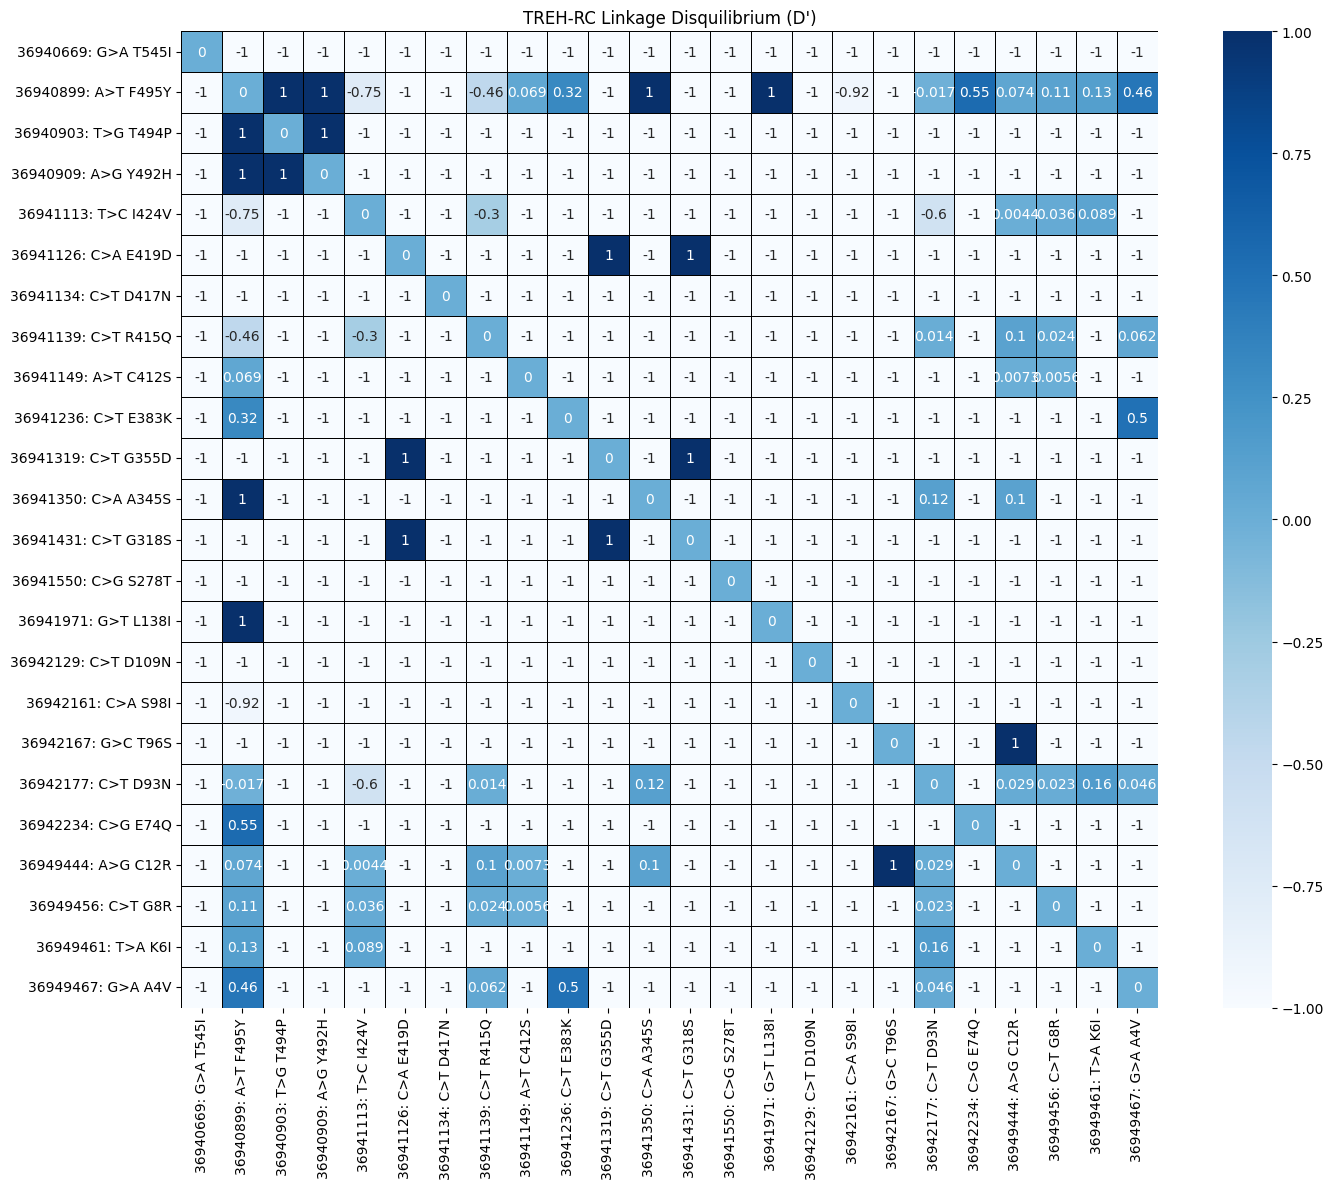

In [75]:
def plot_ld_with_gridspec(ld_df, title="TREH-RC Linkage Disquilibrium (D')"):
    n = ld_df.shape[0]

    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])


    sns.heatmap(
        ld_df,
        cmap="Blues",
        annot=True,
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.5,
        linecolor="black",
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


plot_ld_with_gridspec(ld_df)
